# 02. Εξερευνητική Ανάλυση Δεδομένων (EDA) - DaKS Kassel Dataset

Αυτό το Notebook εστιάζει στην ανάλυση και προετοιμασία των συνθετικών δεδομένων από το **Πανεπιστήμιο του Kassel (DaKS dataset)**. Το σύνολο δεδομένων περιλαμβάνει τηλεμετρία από **273 αιολικά πάρκα** στη Γερμανία για μια περίοδο **500 ημερών**.

###  Στόχοι της Ενότητας
1. **Μαζική Φόρτωση:** Εντοπισμός και καταλογογράφηση των 273 αρχείων CSV.
2. **Ανάλυση Δομής:** Ταυτοποίηση των στηλών και των μονάδων μέτρησης.
3. **Φυσική Μοντελοποίηση:** Προετοιμασία για την εφαρμογή του **Power Law Scaling** στο ύψος της πλήμνης.
4. **Data Validation:** Έλεγχος ποιότητας δεδομένων (Data Quality Gates) μέσω Pydantic.

---
**Σημείωση:** Η οργάνωση των δεδομένων ακολουθεί το πρότυπο `data/raw/kassel_dataset/` για τη διασφάλιση της αμετάβλητης πηγής (immutable source).

In [2]:
import pandas as pd
import glob
import os

# 1. Εντοπισμός των αρχείων
raw_data_path = "../data/raw/kassel_dataset/"
all_files = glob.glob(os.path.join(raw_data_path, "*.csv"))

print(f"Επιτυχία! Βρέθηκαν {len(all_files)} αρχεία CSV στον φάκελο.")

# 2. Διάβασμα ενός δείγματος (το πρώτο αρχείο)
if all_files:
    sample_df = pd.read_csv(all_files[0])
    print(f"\nΣτήλες που εντοπίστηκαν: {list(sample_df.columns)}")
    display(sample_df.head())

Επιτυχία! Βρέθηκαν 545 αρχεία CSV στον φάκελο.

Στήλες που εντοπίστηκαν: ['fcst_time', 'nwp_fcst_horiz_hours', 'T_HAG_2_M', 'RELHUM_HAG_2_M', 'PS_SFC_0_M', 'U_GVL_58_HL', 'V_GVL_58_HL', 'U_GVL_60_HL', 'V_GVL_60_HL', 'ASWDIFDS_SFC_0_M', 'ASWDIRS_SFC_0_M', 'U_GVL_58_HL_m1', 'V_GVL_58_HL_m1', 'U_GVL_60_HL_m1', 'V_GVL_60_HL_m1', 'U_GVL_58_HL_p1', 'V_GVL_58_HL_p1', 'U_GVL_60_HL_p1', 'V_GVL_60_HL_p1']


,fcst_time,nwp_fcst_horiz_hours,T_HAG_2_M,RELHUM_HAG_2_M,PS_SFC_0_M,U_GVL_58_HL,V_GVL_58_HL,U_GVL_60_HL,V_GVL_60_HL,ASWDIFDS_SFC_0_M,ASWDIRS_SFC_0_M,U_GVL_58_HL_m1,V_GVL_58_HL_m1,U_GVL_60_HL_m1,V_GVL_60_HL_m1,U_GVL_58_HL_p1,V_GVL_58_HL_p1,U_GVL_60_HL_p1,V_GVL_60_HL_p1
0,2018-12-08 00:00:00,24,277.105,79.144,93060.656,11.219,-1.154,6.280,-0.324,25.250,15.902,12.240,-1.231,6.980,-0.473,10.205,-2.168,5.744,-1.034
1,2018-12-08 01:00:00,25,276.581,80.629,93124.426,12.240,-1.231,6.980,-0.473,24.238,15.266,11.536,0.346,6.644,0.336,11.219,-1.154,6.280,-0.324
2,2018-12-08 02:00:00,26,276.119,81.829,93155.008,11.536,0.346,6.644,0.336,23.307,14.680,12.284,1.659,7.124,1.062,12.240,-1.231,6.980,-0.473
3,2018-12-08 03:00:00,27,275.763,80.457,93182.648,12.284,1.659,7.124,1.062,22.443,14.137,12.939,0.968,7.530,0.627,11.536,0.346,6.644,0.336
4,2018-12-08 04:00:00,28,275.410,79.750,93234.324,12.939,0.968,7.530,0.627,21.643,13.629,11.216,2.137,6.384,1.384,12.284,1.659,7.124,1.062


In [4]:
import numpy as np
import sys
import os

# Επιτρέπουμε στο Notebook να "βλέπει" τον φάκελο src
sys.path.append(os.path.abspath(".."))
from src.features.physics import apply_power_law_scaling

# 1. Υπολογισμός μέτρου ταχύτητας στα 60 μέτρα (Magnitude)
# WS = sqrt(U^2 + V^2)
sample_df['ws_60m'] = np.sqrt(sample_df['U_GVL_60_HL']**2 + sample_df['V_GVL_60_HL']**2)

# 2. Εφαρμογή του Power Law για να βρούμε την ταχύτητα στα 100μ (Hub Height)
# Χρησιμοποιούμε τη συνάρτηση που υλοποίησες πριν!
sample_df['ws_hub_100m'] = apply_power_law_scaling(
    v_ref=sample_df['ws_60m'], 
    h_ref=60, 
    h_hub=100, 
    alpha=0.143
)

print("✅ Η φυσική μοντελοποίηση εφαρμόστηκε επιτυχώς!")
display(sample_df[['fcst_time', 'ws_60m', 'ws_hub_100m']].head())

✅ Η φυσική μοντελοποίηση εφαρμόστηκε επιτυχώς!


,fcst_time,ws_60m,ws_hub_100m
0,2018-12-08 00:00:00,6.288352,6.764898
1,2018-12-08 01:00:00,6.996008,7.526181
2,2018-12-08 02:00:00,6.652491,7.156631
3,2018-12-08 03:00:00,7.202723,7.748562
4,2018-12-08 04:00:00,7.556059,8.128674


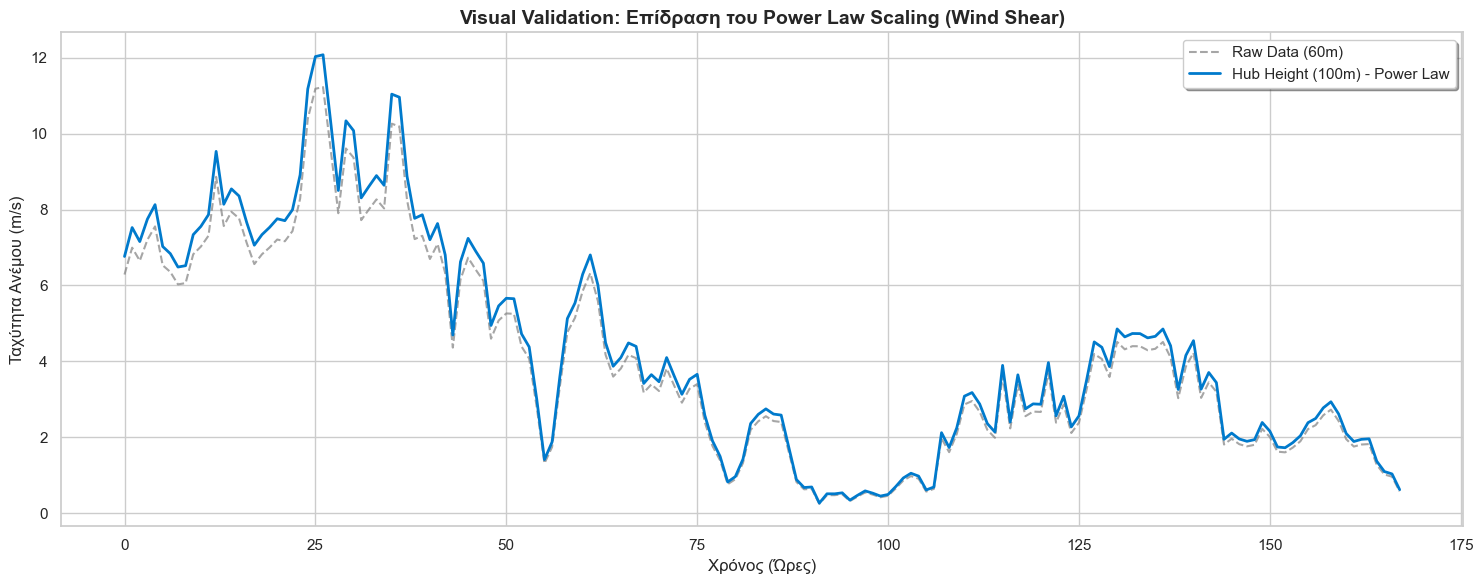

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ρυθμίσεις για εμφάνιση "Publication Quality"
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))

# Παίρνουμε μόνο την πρώτη εβδομάδα (168 ώρες) για να φαίνεται καθαρά
# Αν βάζαμε και τις 500 μέρες, το γράφημα θα ήταν μπερδεμένο
subset = sample_df.iloc[:168]

# 1. Η Αρχική Ταχύτητα (Raw Data - 60m)
plt.plot(subset.index, subset['ws_60m'], label='Raw Data (60m)', color='gray', linestyle='--', alpha=0.7)

# 2. Η Διορθωμένη Ταχύτητα (Hub Height - 100m)
plt.plot(subset.index, subset['ws_hub_100m'], label='Hub Height (100m) - Power Law', color='#007acc', linewidth=2)

# Τίτλοι και Ετικέτες
plt.title("Visual Validation: Επίδραση του Power Law Scaling (Wind Shear)", fontsize=14, fontweight='bold')
plt.ylabel("Ταχύτητα Ανέμου (m/s)", fontsize=12)
plt.xlabel("Χρόνος (Ώρες)", fontsize=12)
plt.legend(frameon=True, fancybox=True, shadow=True)

# Εμφάνιση
plt.tight_layout()
plt.show()